<a href="https://colab.research.google.com/github/Projit1101/Financial-fraud-classification/blob/main/notebooks/graphsage_mini_batch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Check if GPU is available

In [1]:
import torch
print(torch.cuda.is_available())

True


Define the device (Output should be: cuda)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Run this once per session (Access to my Google Drive)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 1: Install Dependencies
# We can rely on Colab's pre-installed PyTorch and just install torch-geometric directly.
!pip install torch-geometric scikit-learn matplotlib pandas
!pip install faiss-cpu

In [5]:
# Cell 2: Data Loading and Preprocessing
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/creditcard.csv')

print("Original Dataset Shape:", df.shape)
print("Fraudulent transactions:", len(df[df['Class'] == 1]))
print("Legitimate transactions:", len(df[df['Class'] == 0]))

# Separate features and labels
# We drop 'Time', 'Class' as they aren't predictive features in the same way
features = df.drop(columns=['Time', 'Class']).values
labels = df['Class'].values

# Standardize features (Mean = 0, Variance = 1)
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Convert to PyTorch tensors
X = torch.tensor(features, dtype=torch.float32).to(device)
y = torch.tensor(labels, dtype=torch.long).to(device)

print("Feature Tensor Shape:", X.shape)
print("Label Tensor Shape:", y.shape)

Original Dataset Shape: (284807, 31)
Fraudulent transactions: 492
Legitimate transactions: 284315
Feature Tensor Shape: torch.Size([284807, 29])
Label Tensor Shape: torch.Size([284807])


In [6]:
# Cell 3: Leakage-Free Graph Construction & Splitting
import faiss
import torch
import numpy as np
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

print("Creating Train/Val/Test splits...")
# 70% Train, 15% Val, 15% Test
train_idx, temp_idx = train_test_split(
    np.arange(features.shape[0]), test_size=0.3, random_state=42, stratify=labels
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=labels[temp_idx]
)

def create_leakage_free_edge_index(features_np, train_indices, k=5):
    print(f"Building KNN graph with k={k} using FAISS (CPU)...")
    d = features_np.shape[1]

    # Build FAISS index strictly on TRAINING data
    train_features = np.ascontiguousarray(features_np[train_indices], dtype=np.float32)
    index = faiss.IndexFlatL2(d)
    index.add(train_features)

    # Search for top k neighbors for ALL nodes
    all_features = np.ascontiguousarray(features_np, dtype=np.float32)
    distances, local_neighbor_indices = index.search(all_features, k)

    # Map local training indices back to global dataset indices
    global_neighbor_indices = train_indices[local_neighbor_indices]

    # cols = senders (train nodes), rows = receivers (all nodes)
    cols = global_neighbor_indices.flatten()
    rows = np.repeat(np.arange(features_np.shape[0]), k)

    # Direction: Train -> All Nodes
    edge_index = torch.tensor(np.vstack((cols, rows)), dtype=torch.long).to(device)
    return edge_index

edge_index = create_leakage_free_edge_index(features, train_idx, k=5)

# Create boolean masks for PyG
train_mask = torch.zeros(features.shape[0], dtype=torch.bool).to(device)
train_mask[train_idx] = True
val_mask = torch.zeros(features.shape[0], dtype=torch.bool).to(device)
val_mask[val_idx] = True
test_mask = torch.zeros(features.shape[0], dtype=torch.bool).to(device)
test_mask[test_idx] = True

data = Data(x=X, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

print("\nGraph Conversion Successful!")
print(f"Number of Edges: {data.num_edges}")

Creating Train/Val/Test splits...
Building KNN graph with k=5 using FAISS (CPU)...

Graph Conversion Successful!
Number of Edges: 1424035


In [7]:
# Cell 4: Define GraphSAGE Model
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch.optim as optim

class GraphSAGE_FraudModel(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features, dropout_rate=0.5):
        super(GraphSAGE_FraudModel, self).__init__()
        # SAGEConv replaces GATConv. It concatenates the target node's
        # features with the aggregated neighborhood features.
        self.conv1 = SAGEConv(in_features, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_features)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

num_features = X.shape[1]
num_classes = 2

# Initialize the new GraphSAGE model
model = GraphSAGE_FraudModel(
    in_features=num_features,
    hidden_dim=16, # Increased slightly as we dropped multiple attention heads
    out_features=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

# Keep your existing Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=0.75, gamma=2.0)

print(model)
print(f"GraphSAGE Model successfully moved to: {device}")

GraphSAGE_FraudModel(
  (conv1): SAGEConv(29, 16, aggr=mean)
  (conv2): SAGEConv(16, 2, aggr=mean)
)
GraphSAGE Model successfully moved to: cuda


#### Restart session after installing dependency for PyQ NeighborLoader

In [ ]:
!pip install pyg_lib torch_sparse torch_scatter -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

## Model Training and Evaluation Results

Starting Mini-Batch Training...
Epoch 10/50, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 20/50, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 30/50, Train Loss: 0.0009, Val Loss: 0.0010
Epoch 40/50, Train Loss: 0.0009, Val Loss: 0.0011
Epoch 50/50, Train Loss: 0.0009, Val Loss: 0.0011


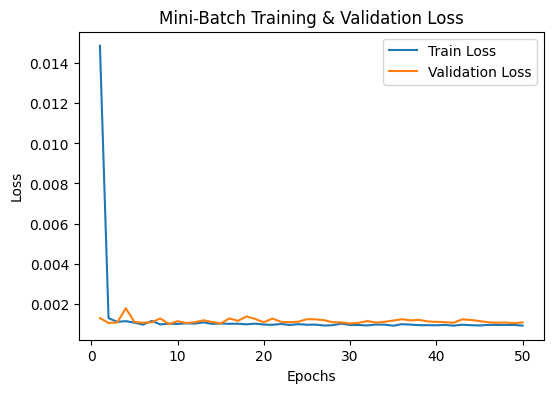

In [9]:
# Cell 5: Mini-Batch Training with NeighborLoader
import matplotlib.pyplot as plt
from torch_geometric.loader import NeighborLoader

# 1. Initialize NeighborLoaders
# Sample 15 neighbors in the first layer, 10 in the second
train_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=data.train_mask,
    shuffle=True
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=data.val_mask,
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=data.test_mask,
)

# 2. Mini-Batch Training Loop
epochs = 50
train_losses = []
val_losses = []

print("Starting Mini-Batch Training...")
for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)

        # NeighborLoader places the target (seed) nodes at the beginning of the batch
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch.batch_size

    avg_train_loss = total_train_loss / int(data.train_mask.sum())
    train_losses.append(avg_train_loss)

    # Validation Loop
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])
            total_val_loss += loss.item() * batch.batch_size

    avg_val_loss = total_val_loss / int(data.val_mask.sum())
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Mini-Batch Training & Validation Loss')
plt.legend()
plt.show()

In [11]:
# Cell 6: Optimal Threshold Tuning & Final Evaluation (Mini-Batch)
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import torch

def get_loader_predictions(loader):
    model.eval()
    all_probs = []
    all_true = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            probs = torch.exp(out[:batch.batch_size, 1])

            all_probs.append(probs.cpu())
            all_true.append(batch.y[:batch.batch_size].cpu())

    return torch.cat(all_probs).numpy(), torch.cat(all_true).numpy()

# --- 1. TUNE ON VALIDATION SET ---
y_prob_val, y_true_val = get_loader_predictions(val_loader)

precisions, recalls, thresholds = precision_recall_curve(y_true_val, y_prob_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"--- Tuning on Validation Set ---")
print(f"Optimal threshold for max F1 is: {optimal_threshold:.4f}")
print(f"Expected Val Precision: {precisions[best_idx]:.4f} | Val Recall: {recalls[best_idx]:.4f}")

# --- 2. EVALUATE ON UNSEEN TEST SET ---
y_prob_test, y_true_test = get_loader_predictions(test_loader)
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

print(f"\n--- Final Unbiased Test Set Results (Threshold: {optimal_threshold:.4f}) ---")
print(f"Accuracy:  {accuracy_score(y_true_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_true_test, y_pred_test, zero_division=1):.4f}")
print(f"Recall:    {recall_score(y_true_test, y_pred_test, zero_division=1):.4f}")
print(f"F1 Score:  {f1_score(y_true_test, y_pred_test, zero_division=1):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_true_test, y_prob_test):.4f}")

--- Tuning on Validation Set ---
Optimal threshold for max F1 is: 0.5481
Expected Val Precision: 0.7714 | Val Recall: 0.7297

--- Final Unbiased Test Set Results (Threshold: 0.5481) ---
Accuracy:  0.9995
Precision: 0.9048
Recall:    0.7703
F1 Score:  0.8321
AUC-ROC:   0.9401


In [12]:
# Cell 7: Save and Download the Model Checkpoint
import torch
from google.colab import files

# Define the file name
model_save_path = 'graphSAGE_mini_batch.pth'

# Save the model's learned weights (state dictionary)
torch.save(model.state_dict(), model_save_path)
print(f"Model successfully saved to Colab environment as: {model_save_path}")

# Download the file to your local computer for permanent safekeeping
print("Downloading to your local machine...")
files.download(model_save_path)

Model successfully saved to Colab environment as: graphSAGE_mini_batch.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>